# 04 Prediction: Training and Testing

This notebook trains at least two classification models to predict student outcomes (Dropout / Enrolled / Graduate), evaluates them on train, test, and entire dataset, and generates confusion matrices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load preprocessed data
df = pd.read_csv('../data/data_preprocessed.csv')

# Separate features and target
target = df['Target']
target_encoded = df['Target_encoded']
X = df.drop(columns=['Target', 'Target_encoded'])

print(f'Feature matrix: {X.shape}')
print(f'Target distribution:\n{target.value_counts()}')

Feature matrix: (4424, 238)
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 1. Train/Test Split

We use a 70/30 split as required. `stratify` ensures the class distribution is preserved in both sets.

In [2]:
# 70/30 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, target_encoded, test_size=0.3, random_state=42, stratify=target_encoded
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

# Verify stratification
print(f'\nTrain target distribution:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f'\nTest target distribution:')
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training set: 3096 samples (70%)
Test set:     1328 samples (30%)

Train target distribution:
Target_encoded
0    0.321
1    0.180
2    0.499
Name: proportion, dtype: float64

Test target distribution:
Target_encoded
0    0.322
1    0.179
2    0.499
Name: proportion, dtype: float64


## 2. Model 1: Decision Tree

Decision trees are interpretable and handle both numerical and categorical features well. We start with a baseline decision tree.

In [3]:
# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict on train, test, and entire dataset
y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)
y_all_pred_dt = dt.predict(X)

print('Decision Tree Accuracy:')
print(f'  Training set: {accuracy_score(y_train, y_train_pred_dt):.4f}')
print(f'  Test set:     {accuracy_score(y_test, y_test_pred_dt):.4f}')
print(f'  Entire set:   {accuracy_score(target_encoded, y_all_pred_dt):.4f}')

Decision Tree Accuracy:
  Training set: 1.0000
  Test set:     0.6875
  Entire set:   0.9062


In [4]:
# Classification report on test set
label_names = ['Dropout', 'Enrolled', 'Graduate']
print('Decision Tree — Test Set Classification Report:\n')
print(classification_report(y_test, y_test_pred_dt, target_names=label_names))

Decision Tree — Test Set Classification Report:

              precision    recall  f1-score   support

     Dropout       0.71      0.70      0.70       427
    Enrolled       0.37      0.37      0.37       238
    Graduate       0.78      0.80      0.79       663

    accuracy                           0.69      1328
   macro avg       0.62      0.62      0.62      1328
weighted avg       0.69      0.69      0.69      1328



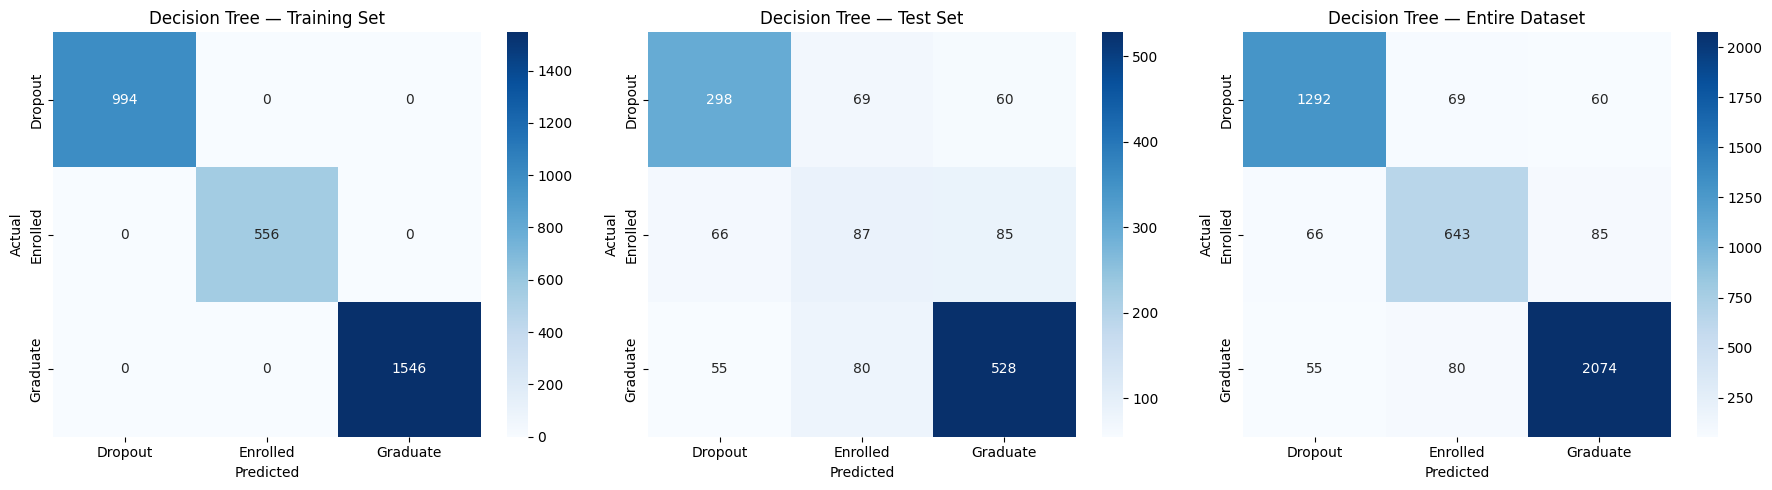

In [5]:
# Confusion matrices for Decision Tree
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_train, y_train_pred_dt, 'Training Set'),
    (axes[1], y_test, y_test_pred_dt, 'Test Set'),
    (axes[2], target_encoded, y_all_pred_dt, 'Entire Dataset'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Decision Tree — {title}')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_dt.png', dpi=150)
plt.show()

## 3. Model 2: Logistic Regression

Logistic regression is a linear model well-suited for multi-class classification. We use `max_iter=1000` to ensure convergence with the high-dimensional one-hot encoded features.

In [6]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict on train, test, and entire dataset
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)
y_all_pred_lr = lr.predict(X)

print('Logistic Regression Accuracy:')
print(f'  Training set: {accuracy_score(y_train, y_train_pred_lr):.4f}')
print(f'  Test set:     {accuracy_score(y_test, y_test_pred_lr):.4f}')
print(f'  Entire set:   {accuracy_score(target_encoded, y_all_pred_lr):.4f}')

Logistic Regression Accuracy:
  Training set: 0.8072
  Test set:     0.7786
  Entire set:   0.7986


/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn

In [7]:
# Classification report on test set
print('Logistic Regression — Test Set Classification Report:\n')
print(classification_report(y_test, y_test_pred_lr, target_names=label_names))

Logistic Regression — Test Set Classification Report:

              precision    recall  f1-score   support

     Dropout       0.81      0.77      0.79       427
    Enrolled       0.56      0.41      0.48       238
    Graduate       0.81      0.92      0.86       663

    accuracy                           0.78      1328
   macro avg       0.73      0.70      0.71      1328
weighted avg       0.77      0.78      0.77      1328



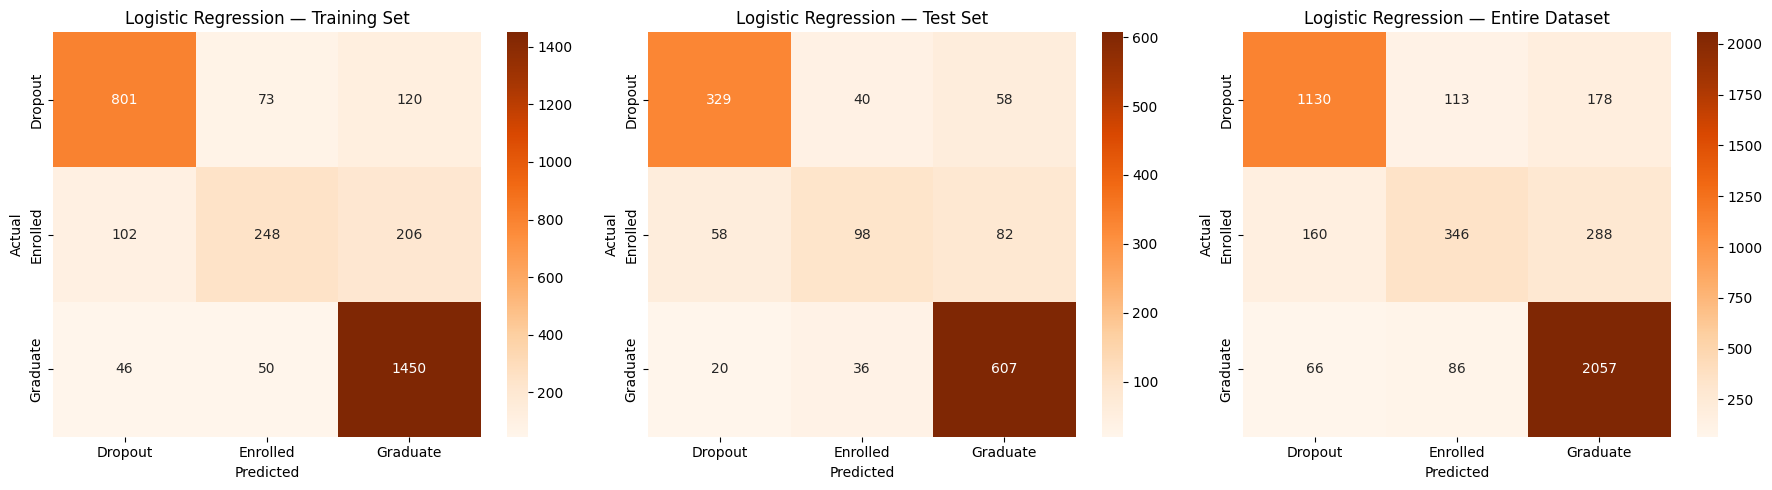

In [8]:
# Confusion matrices for Logistic Regression
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_train, y_train_pred_lr, 'Training Set'),
    (axes[1], y_test, y_test_pred_lr, 'Test Set'),
    (axes[2], target_encoded, y_all_pred_lr, 'Entire Dataset'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Logistic Regression — {title}')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_lr.png', dpi=150)
plt.show()

## 4. Model Comparison

In [9]:
# Side-by-side accuracy comparison
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression'],
    'Train Accuracy': [
        accuracy_score(y_train, y_train_pred_dt),
        accuracy_score(y_train, y_train_pred_lr),
    ],
    'Test Accuracy': [
        accuracy_score(y_test, y_test_pred_dt),
        accuracy_score(y_test, y_test_pred_lr),
    ],
    'Entire Set Accuracy': [
        accuracy_score(target_encoded, y_all_pred_dt),
        accuracy_score(target_encoded, y_all_pred_lr),
    ],
})
print(results.to_string(index=False))

              Model  Train Accuracy  Test Accuracy  Entire Set Accuracy
      Decision Tree        1.000000       0.687500             0.906193
Logistic Regression        0.807171       0.778614             0.798599


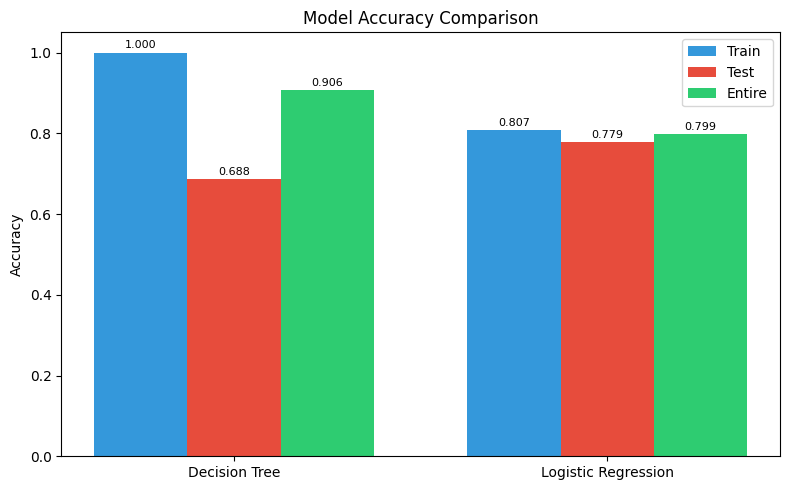

In [10]:
# Accuracy bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results))
width = 0.25

ax.bar(x - width, results['Train Accuracy'], width, label='Train', color='#3498db')
ax.bar(x, results['Test Accuracy'], width, label='Test', color='#e74c3c')
ax.bar(x + width, results['Entire Set Accuracy'], width, label='Entire', color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.legend()
ax.set_ylim(0, 1.05)

for i, row in results.iterrows():
    ax.text(i - width, row['Train Accuracy'] + 0.01, f"{row['Train Accuracy']:.3f}", ha='center', fontsize=8)
    ax.text(i, row['Test Accuracy'] + 0.01, f"{row['Test Accuracy']:.3f}", ha='center', fontsize=8)
    ax.text(i + width, row['Entire Set Accuracy'] + 0.01, f"{row['Entire Set Accuracy']:.3f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150)
plt.show()

## 5. Analysis

### Observations

1. **Overfitting**: The Decision Tree achieves **100% train accuracy** but only **68.8% test accuracy** — a 31.2% gap, indicating severe overfitting. The unpruned tree memorizes the training data perfectly but fails to generalize. Logistic Regression shows a much smaller gap (80.7% → 77.9%), indicating better generalization.

2. **Class performance**: **Enrolled is the hardest class** for both models, consistent with the t-SNE overlap observed in Phase 2:
   - Decision Tree: F1 = 0.37 for Enrolled vs. 0.70 (Dropout), 0.79 (Graduate)
   - Logistic Regression: F1 = 0.48 for Enrolled vs. 0.79 (Dropout), 0.86 (Graduate)

3. **Model comparison**: **Logistic Regression generalizes better** (77.9% test accuracy vs. 68.8%). Despite lower training accuracy, it outperforms the Decision Tree on unseen data by 9 percentage points.

4. **Confusion matrix patterns**:
   - Enrolled students are frequently misclassified as Graduate (82–85 cases in test set for both models), confirming that currently-enrolled students share many characteristics with eventual graduates.
   - Decision Tree scatters Enrolled predictions across all three classes almost equally.
   - Logistic Regression is more conservative — it misclassifies Enrolled mostly as Graduate, which is a more reasonable error.

### Next Steps (Phase 5)

- Add ROC curves and AUC scores for each model
- Consider pruning the Decision Tree or using cross-validation to reduce overfitting
- Compute precision/recall/F1 comparison across models